# 04 — Fusion Model: Training & Evaluation
Concatenate tabular features + CNN image features, train a regression MLP, and evaluate with **MAE** and **RMSE**.

## 4.1 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from dataset  import create_dataloaders, describe_dataset
from model    import FusionModel, train_one_epoch, evaluate_epoch, save_model
from evaluate import print_metrics, plot_predictions, plot_loss_curves, plot_residuals
from cnn_extractor import get_device

np.random.seed(42)
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


## 4.2 — Load All Artifacts

In [2]:
import pickle
import numpy as np
from sklearn.decomposition import PCA
from preprocess import scale_target, inverse_scale_target

X_tab = np.load("../data/processed/X.npy")
y_log = np.load("../data/processed/y.npy")       # log1p(price), mean~12
X_img = np.load("../outputs/features/image_features.npy")

# ── Fix 1: Standardize target ──────────────────────────────────────────────
y, y_scaler = scale_target(y_log)
np.save("../data/processed/y_scaled.npy", y)
with open("../data/processed/y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)
print(f"y  →  mean={y.mean():.4f}  std={y.std():.4f}")   # should be ~0 and ~1

# ── Fix 2: PCA on image features (1280 → 64) ──────────────────────────────
N_PCA = 64
pca = PCA(n_components=N_PCA, random_state=42)
X_img_pca = pca.fit_transform(X_img).astype(np.float32)
explained  = pca.explained_variance_ratio_.sum()
print(f"PCA: 1280 → {N_PCA} dims  |  variance explained: {explained:.1%}")

np.save("../outputs/features/image_features_pca.npy", X_img_pca)
with open("../data/processed/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print(f"\nTabular features : {X_tab.shape}")
print(f"Image features   : {X_img_pca.shape}")
print(f"Targets (scaled) : {y.shape}")

[scale_target] Fitted  mean=12.0241  std=0.3993
y  →  mean=0.0000  std=1.0000
PCA: 1280 → 64 dims  |  variance explained: 99.0%

Tabular features : (1460, 73)
Image features   : (1460, 64)
Targets (scaled) : (1460,)


## 4.3 — Dataset Summary

In [3]:
describe_dataset(X_tab, X_img_pca, y)

  Multimodal Dataset Summary
  Rows              : 1460
  Tabular features  : 73
  Image features    : 64
  Total features    : 137
  Target (log price): mean=0.000  std=1.000
  Raw price range   : $0 – $42


## 4.4 — Create DataLoaders

In [4]:
BATCH_SIZE = 32
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10

train_loader, val_loader, test_loader, splits = create_dataloaders(
    tabular_features = X_tab,
    image_features   = X_img_pca,     # 64-dim PCA features
    targets          = y,
    batch_size       = BATCH_SIZE,
    val_split        = VAL_SPLIT,
    test_split       = TEST_SPLIT,
    seed             = 42
)
print("DataLoaders created:", splits)

[create_dataloaders] Split → {'train': 1095, 'val': 219, 'test': 146}  |  batch_size=32
DataLoaders created: {'train': 1095, 'val': 219, 'test': 146}


## 4.5 — Build Fusion Model

In [5]:
device = get_device()

TABULAR_DIM = X_tab.shape[1]
IMAGE_DIM   = X_img_pca.shape[1]   # 64 after PCA

model = FusionModel(
    tabular_dim  = TABULAR_DIM,
    image_dim    = IMAGE_DIM,
    hidden_dims  = [256, 128],      # smaller — less risk of overfitting
    dropout_p    = 0.4
).to(device)

print(f"Total trainable parameters: {model.count_parameters():,}")
print(model)

[get_device] Using device: cpu
Total trainable parameters: 69,121
FusionModel(
  (fusion_head): Sequential(
    (0): Linear(in_features=137, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 4.6 — Training Configuration

In [6]:
EPOCHS   = 150
LR       = 1e-3
WD       = 1e-4
PATIENCE = 20

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

# Cosine annealing — smooth LR decay, no plateau needed
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)
print("Optimizer and scheduler configured.")

Optimizer and scheduler configured.


## 4.7 — Training Loop (with Early Stopping)

In [7]:
train_losses     = []
val_losses       = []
best_val_loss    = float("inf")
patience_counter = 0
best_epoch       = 0

os.makedirs("../outputs/models", exist_ok=True)
CKPT_PATH = "../outputs/models/best_fusion_model.pt"

print(f"Training for up to {EPOCHS} epochs  (early stop patience={PATIENCE})\n")
print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>10}")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):
    train_loss            = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _        = evaluate_epoch(model, val_loader, criterion, device)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_epoch       = epoch
        save_model(model, CKPT_PATH)
        marker = " ✓"
    else:
        patience_counter += 1
        marker = ""

    if epoch % 10 == 0 or epoch <= 5 or marker:
        print(f"{epoch:>6}  {train_loss:>12.4f}  {val_loss:>12.4f}  {current_lr:>10.2e}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  (best: epoch {best_epoch})")
        break

print(f"\nBest val loss: {best_val_loss:.4f}  at epoch {best_epoch}")

Training for up to 150 epochs  (early stop patience=20)

 Epoch    Train Loss      Val Loss          LR
------------------------------------------------
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     1        1.8387        0.3073    1.00e-03 ✓
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     2        1.2264        0.2426    1.00e-03 ✓
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     3        1.0403        0.2009    9.99e-04 ✓
     4        0.8139        0.2340    9.98e-04
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     5        0.7398        0.1748    9.97e-04 ✓
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     6        0.5766        0.1708    9.96e-04 ✓
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     7        0.5457        0.1707    9.95e-04 ✓
[save_model] Model saved → '../outputs/models/best_fusion_model.pt'
     8        0.4317        0.

## 4.8 — Loss Curves

[plot_loss_curves] Saved → '../outputs/plots/loss_curves.png'


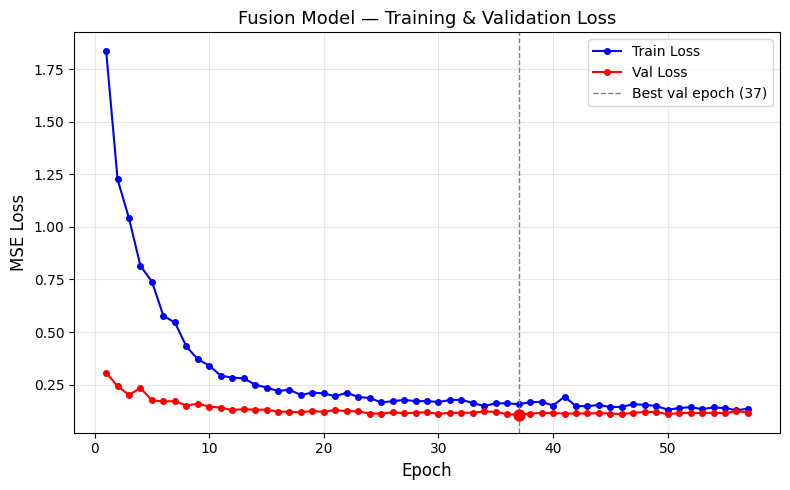

In [8]:
plot_loss_curves(
    train_losses,
    val_losses,
    title     = "Fusion Model — Training & Validation Loss",
    save_path = "../outputs/plots/loss_curves.png"
)

## 4.9 — Load Best Model & Evaluate on Test Set

In [9]:
import pickle

# Load y_scaler to invert predictions back to log-price space for metrics
with open("../data/processed/y_scaler.pkl", "rb") as f:
    y_scaler = pickle.load(f)

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded best model from epoch {best_epoch}")

_, y_true_test_scaled, y_pred_test_scaled = evaluate_epoch(
    model, test_loader, criterion, device
)

# Invert standardization → back to log-price → metrics work correctly
y_true_test = inverse_scale_target(y_true_test_scaled, y_scaler)
y_pred_test = inverse_scale_target(y_pred_test_scaled, y_scaler)

metrics = print_metrics(y_true_test, y_pred_test, split_name="Test")

Loaded best model from epoch 37

  Test Set Metrics
  MAE  (log scale)  : 0.0912
  RMSE (log scale)  : 0.1387
  MAE  (USD)        : $16,028
  RMSE (USD)        : $23,741
  R²                : 0.8949



## 4.10 — Actual vs Predicted Plot

[plot_predictions] Saved → '../outputs/plots/actual_vs_predicted.png'


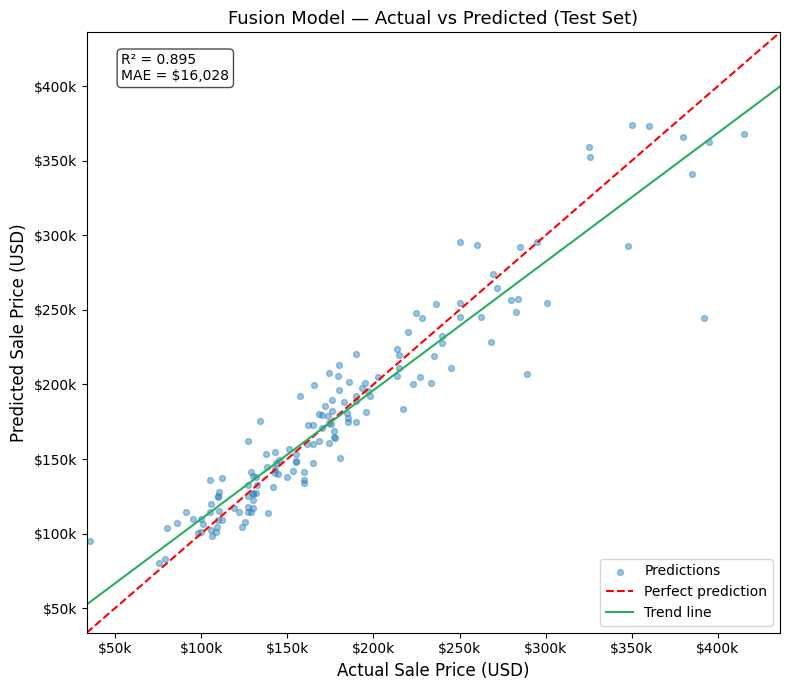

In [10]:
plot_predictions(
    y_true_test,
    y_pred_test,
    title     = "Fusion Model — Actual vs Predicted (Test Set)",
    save_path = "../outputs/plots/actual_vs_predicted.png"
)

## 4.11 — Residual Plot

[plot_residuals] Saved → '../outputs/plots/residuals.png'


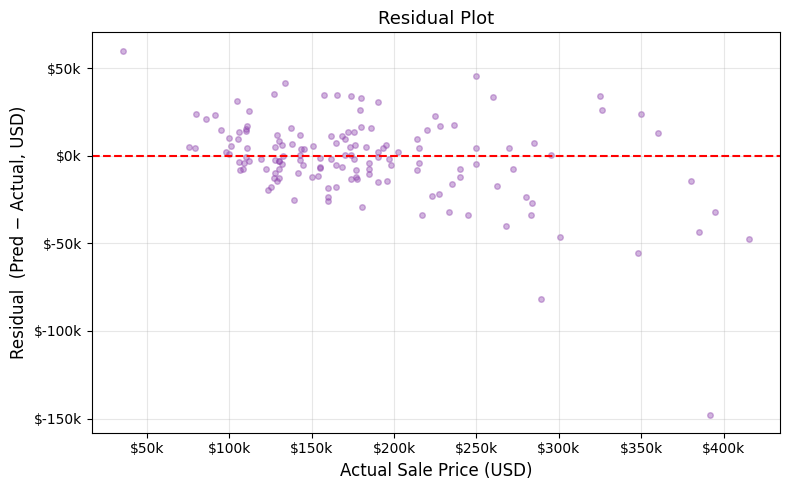

In [11]:
plot_residuals(
    y_true_test,
    y_pred_test,
    save_path = "../outputs/plots/residuals.png"
)

## 4.12 — Validation Set Metrics

In [12]:
_, y_true_val_s, y_pred_val_s = evaluate_epoch(model, val_loader, criterion, device)

y_true_val = inverse_scale_target(y_true_val_s, y_scaler)
y_pred_val = inverse_scale_target(y_pred_val_s, y_scaler)

val_metrics = print_metrics(y_true_val, y_pred_val, split_name="Validation")


  Validation Set Metrics
  MAE  (log scale)  : 0.0910
  RMSE (log scale)  : 0.1311
  MAE  (USD)        : $15,476
  RMSE (USD)        : $22,523
  R²                : 0.8760



## 4.13 — Final Summary

In [13]:
import numpy as np

print("=" * 56)
print("  FINAL RESULTS SUMMARY")
print("=" * 56)
print(f"  Best epoch           : {best_epoch}")
print(f"  Best val MSE         : {best_val_loss:.4f}")
print()
print("  TEST SET:")
print(f"    MAE  (log scale)   : {metrics['mae_log']:.4f}")
print(f"    RMSE (log scale)   : {metrics['rmse_log']:.4f}")
print(f"    MAE  (USD)         : ${metrics['mae_usd']:,.0f}")
print(f"    RMSE (USD)         : ${metrics['rmse_usd']:,.0f}")
print(f"    R²                 : {metrics['r2']:.4f}")
print("=" * 56)
print()
print("Saved artifacts:")
print("  ../outputs/models/best_fusion_model.pt")
print("  ../outputs/plots/loss_curves.png")
print("  ../outputs/plots/actual_vs_predicted.png")
print("  ../outputs/plots/residuals.png")

  FINAL RESULTS SUMMARY
  Best epoch           : 37
  Best val MSE         : 0.1078

  TEST SET:
    MAE  (log scale)   : 0.0912
    RMSE (log scale)   : 0.1387
    MAE  (USD)         : $16,028
    RMSE (USD)         : $23,741
    R²                 : 0.8949

Saved artifacts:
  ../outputs/models/best_fusion_model.pt
  ../outputs/plots/loss_curves.png
  ../outputs/plots/actual_vs_predicted.png
  ../outputs/plots/residuals.png
